<div style="background: linear-gradient(135deg, #1e1b4b, #312e81); color:white; padding:25px; border-radius:10px;
            text-align:center; font-family:'Segoe UI', sans-serif;">

  <h1 style="margin-bottom:8px;"> WikiArt Image Classification</h1>
  <h3 style="margin-top:0; font-style:italic; font-weight:normal; color:#a5b4fc;">
    Transfer Learning with EfficientNetV2-S
  </h3>

  <hr style="width:60%; border:1px solid #6366f1; margin:15px auto;">

  <p style="margin:5px 0; font-size:15px;">
    <b>Group Project</b> - Deep Learning (2025/2026)
  </p>
  <p style="margin:0; font-size:13px; color:#c7d2fe;">
    Master in Data Science and Advanced Analytics - Nova Information Management School
  </p>
</div>

<br>

<div style="background-color:#1e293b; color:#e0e7ff; padding:15px 20px; border-left:5px solid #6366f1;
            border-radius:6px; font-family:'Segoe UI', sans-serif; font-size:14px;">

  <b>Notebook Description</b><br>
  Transfer learning approach using an <b>EfficientNetV2-S</b> backbone pretrained on ImageNet,
  fine-tuned for artist classification on the WikiArt dataset.
  EfficientNetV2 combines Fused-MBConv blocks and squeeze-and-excitation, giving a stronger inductive bias for
  fine-grained texture features (brushstrokes, palette) than ResNet50 at a similar parameter count.
  The model is evaluated using macro F1 score to account for class imbalance across the 23 artist categories.
</div>

<br>


**<h3>Table of Contents</h3>**
* [1. Environment Setup](#1-environment-setup)
* [2. Model Implementation](#2-model)
* [3. Model Evaluation](#3-model2)


<div id="1-environment-setup" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#a5b4fc;">
    1. Setup
  </h2>
</div>


## 1.1 Libraries imports

In [1]:
import sys
import os

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import yaml

from tensorflow.keras.applications import EfficientNetV2S

sys.path.append(os.path.abspath('../src'))

from utils import (
    evaluate_model,
    load_datasets,
    plot_learning_curves,
    save_history,
    set_seeds,
    predict_tta,
    evaluate_from_predictions,
)

# load config
with open('../config.yml', 'r') as f:
    config = yaml.safe_load(f)

## 1.2 Google Colab Setup

The EfficientNetV2-S experiments were run on Google Colab (T4, 16 GB VRAM) for the same reason as the ResNet50 run: the fine-tuning phase roughly doubles memory usage (unfrozen activations + gradients), which pushes our local GPUS over its limit. The notebook auto-detects the environment (`IN_COLAB` flag) and switches between local and Drive-mounted paths.

In [3]:
SEED = 42

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')
    DRIVE_PROJECT = '/content/drive/MyDrive/Deep-learning-project'
    LOCAL_DATA = '/content/data'

    if not os.path.exists(LOCAL_DATA):
        print("Unzipping dataset from Drive...")
        !unzip -q "$DRIVE_PROJECT/data.zip" -d /content/
        print("Done.")
    else:
        print(f"{LOCAL_DATA} already exists, skipping unzip.")

    sys.path.append(f'{DRIVE_PROJECT}/src')
    CONFIG_PATH = f'{DRIVE_PROJECT}/config.yml'
else:
    sys.path.append(os.path.abspath('../src'))
    CONFIG_PATH = '../config.yml'

from utils import *

# Load config
import yaml
with open(CONFIG_PATH, 'r') as f:
    config = yaml.safe_load(f)

set_seeds(config['seed'])

# Paths: in Colab override to local copies, otherwise use config paths
if IN_COLAB:
    train_dir = f'{LOCAL_DATA}/train'
    val_dir   = f'{LOCAL_DATA}/val'
    test_dir  = f'{LOCAL_DATA}/test'
else:
    train_dir = config['paths']['train_dir']
    val_dir   = config['paths']['val_dir']
    test_dir  = config['paths']['test_dir']

# Checkpoint paths
if IN_COLAB:
    CHECKPOINT_DIR = f'{DRIVE_PROJECT}/models_results/effnetv2s'
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    checkpoint_path = f'{CHECKPOINT_DIR}/effnetv2s_v1_best.keras'
    history_path    = f'{CHECKPOINT_DIR}/effnetv2s_historyv1.json'
else:
    default_ckpt = '../models/effnetv2s/effnetv2s_v1_best.keras'
    default_hist = '../models/effnetv2s/effnetv2s_historyv1.json'
    try:
        checkpoint_path = config['models']['effnetv2s']['checkpoint']
        history_path    = config['models']['effnetv2s']['history']
    except KeyError:
        checkpoint_path = default_ckpt
        history_path    = default_hist
    os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/data already exists, skipping unzip.


<div id="2-model" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#a5b4fc;">
    2. Model Implementation
  </h2>
</div>


## 2.1 Transfer Learning using EfficientNetV2-S



In [ ]:
IMG_SIZE = (300, 300)
BATCH_SIZE = 16
NUM_CLASSES = 23

train_ds, val_ds, test_ds, class_names = load_datasets(
    train_dir, val_dir, test_dir,
    img_size=IMG_SIZE, batch_size=BATCH_SIZE,
)

# Data augmentation: kept identical to the ResNet50 so the controlled variables are only resolution and unfreeze depth.
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
], name="data_augmentation")

# MixUp
def mixup_batch(images, labels, alpha=0.2):
    batch_size = tf.shape(images)[0]
    gamma1 = tf.random.gamma([batch_size], alpha)
    gamma2 = tf.random.gamma([batch_size], alpha)
    lam = gamma1 / (gamma1 + gamma2)
    lam_img = tf.reshape(lam, [batch_size, 1, 1, 1])
    lam_lab = tf.reshape(lam, [batch_size, 1])
    idx = tf.random.shuffle(tf.range(batch_size))
    mixed_images = lam_img * images + (1 - lam_img) * tf.gather(images, idx)
    mixed_labels = lam_lab * labels + (1 - lam_lab) * tf.gather(labels, idx)
    return mixed_images, mixed_labels

AUTOTUNE = tf.data.AUTOTUNE

# shuffle(128) + prefetch(2): tighter bounded buffers than before (was 256 / 2)
# to leave more headroom for the 300x300 images. 128 is still plenty of
# randomness for a 9300-image training set.
train_ds = (train_ds
            .shuffle(128, seed=SEED, reshuffle_each_iteration=True)
            .map(lambda x, y: (data_augmentation(x, training=True), y),
                 num_parallel_calls=AUTOTUNE)
            .map(mixup_batch, num_parallel_calls=AUTOTUNE)
            .prefetch(2))
val_ds  = val_ds.prefetch(2)
test_ds = test_ds.prefetch(2)

Found 9282 files belonging to 23 classes.
Found 1980 files belonging to 23 classes.
Found 2012 files belonging to 23 classes.
Classes (23): ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']


In [6]:
base_model = EfficientNetV2S(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMG_SIZE, 3),
)
base_model.trainable = False

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs, name="effnetv2s_transfer_v2")
model.summary()

Model: "effnetv2s_transfer_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 10, 10, 1280)   │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │        11,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,004,151 (80.12 MB)

 Trainable params: 670,231 (2.56 MB)

 Non-trainable params: 20,333,920 (77.57 MB)

### Phase 1 - Frozen backbone

We train only the new head with a higher LR (1e-4) so the classifier adapts to our 23 artists before touching pretrained features. AdamW + label smoothing (0.1) are kept identical to the ResNet50 run so that any improvement is attributable to the backbone, not to the optimizer.

EarlyStopping patience is set to 6 (vs 8 in the ResNet50 notebook). The frozen-backbone plateau is reached fast because gradients only update ~0.5M head parameters, so we save budget for phase 2.


In [7]:
local_checkpoint_path = "/content/effnetv2s_v2_best.keras"

model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-4),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy", keras.metrics.F1Score(average="macro", name="f1_macro")],
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_f1_macro", mode="max", patience=10, restore_best_weights=True
)

checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=local_checkpoint_path,
    monitor="val_f1_macro", mode="max",
    save_best_only=True, verbose=1,
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_f1_macro", mode="max", factor=0.5, patience=4, min_lr=1e-7, verbose=1
)

history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop, reduce_lr, checkpoint_callback],
)

import shutil
phase1_drive_path = checkpoint_path.replace(".keras", "_phase1.keras")
shutil.copy(local_checkpoint_path, phase1_drive_path)
print(f"Phase 1 best model copied to Drive: {phase1_drive_path}")

Epoch 1/30
581/581 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.1219 - f1_macro: 0.0948 - loss: 3.8788
Epoch 1: val_f1_macro improved from None to 0.41387, saving model to /content/effnetv2s_v2_best.keras

Epoch 1: finished saving model to /content/effnetv2s_v2_best.keras
581/581 ━━━━━━━━━━━━━━━━━━━━ 344s 461ms/step - accuracy: 0.1830 - f1_macro: 0.1476 - loss: 3.4837 - val_accuracy: 0.4783 - val_f1_macro: 0.4139 - val_loss: 2.0919 - learning_rate: 1.0000e-04
Epoch 2/30
581/581 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.3027 - f1_macro: 0.2492 - loss: 2.9655
Epoch 2: val_f1_macro improved from 0.41387 to 0.47552, saving model to /content/effnetv2s_v2_best.keras

Epoch 2: finished saving model to /content/effnetv2s_v2_best.keras
581/581 ━━━━━━━━━━━━━━━━━━━━ 202s 341ms/step - accuracy: 0.3204 - f1_macro: 0.2715 - loss: 2.8909 - val_accuracy: 0.5338 - val_f1_macro: 0.4755 - val_loss: 1.9129 - learning_rate: 1.0000e-04
Epoch 3/30
581/581 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accur

### Phase 2 - Fine-tuning (partial unfreeze)

We unfreeze from **`block5`** onwards. In EfficientNetV2-S, top-level blocks are named `block1_` ... `block6_`, so gating on `layer.name.startswith("block5")` unfreezes the two deepest stages (mix of MBConv and the last Fused-MBConv blocks) - the analogue of unfreezing `conv3_block1` onwards in ResNet50 (conservative, high-level features only).

**Critical**: every `BatchNormalization` layer in the backbone stays frozen. Unfreezing BN with a small batch size (12) destabilizes running statistics and is a known source of regression when fine-tuning ImageNet CNNs.


In [ ]:
# Unfreeze block4 onwards: in EfficientNetV2-S this means the last three top-level
# stages, ~55-60% of backbone parameters.
base_model.trainable = True
set_trainable = False
for layer in base_model.layers:
    if layer.name.startswith("block4"):
        set_trainable = True
    layer.trainable = set_trainable
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Trainable layers in backbone: {trainable_count} / {len(base_model.layers)}")

# Lower LR than v1 phase 2 (5e-6 vs 1e-5) because more params are unfrozen
# and we want to avoid destabilizing mid-level features.
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=5e-6, weight_decay=1e-4),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy", keras.metrics.F1Score(average="macro", name="f1_macro")],
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_f1_macro", mode="max", patience=12, restore_best_weights=True
)

checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=local_checkpoint_path,
    monitor="val_f1_macro", mode="max",
    save_best_only=True, verbose=1,
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_f1_macro", mode="max", factor=0.5, patience=5, min_lr=1e-8, verbose=1
)

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=[early_stop, reduce_lr, checkpoint_callback],
)

import shutil
shutil.copy(local_checkpoint_path, checkpoint_path)
print(f"Phase 2 best model copied to Drive: {checkpoint_path}")

Trainable layers in backbone: 356 / 513
Epoch 1/40
581/581 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.6001 - f1_macro: 0.5476 - loss: 1.9008
Epoch 1: val_f1_macro improved from None to 0.70156, saving model to /content/effnetv2s_v2_best.keras

Epoch 1: finished saving model to /content/effnetv2s_v2_best.keras
581/581 ━━━━━━━━━━━━━━━━━━━━ 414s 514ms/step - accuracy: 0.6141 - f1_macro: 0.5605 - loss: 1.8499 - val_accuracy: 0.7374 - val_f1_macro: 0.7016 - val_loss: 1.4042 - learning_rate: 5.0000e-06
Epoch 2/40
581/581 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.6505 - f1_macro: 0.5913 - loss: 1.8006
Epoch 2: val_f1_macro improved from 0.70156 to 0.72701, saving model to /content/effnetv2s_v2_best.keras

Epoch 2: finished saving model to /content/effnetv2s_v2_best.keras
581/581 ━━━━━━━━━━━━━━━━━━━━ 223s 373ms/step - accuracy: 0.6546 - f1_macro: 0.6006 - loss: 1.7907 - val_accuracy: 0.7586 - val_f1_macro: 0.7270 - val_loss: 1.3670 - learning_rate: 5.0000e-06
Epoch 3/40
581/581 ━━

<div id="3-model2" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#a5b4fc;">
    3. Model Evaluation
  </h2>
</div>


### Learning Curves

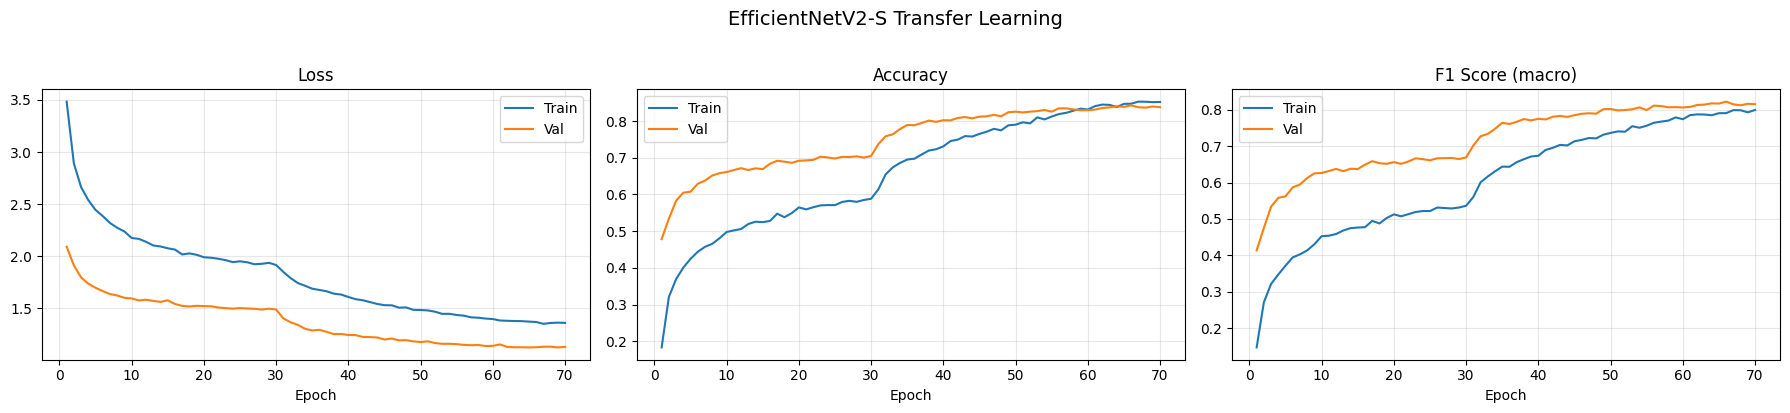

Best epoch (lowest val_loss): 65
  Val Loss: 1.1256
  Val Acc:  0.8389
  Val F1:   0.8167


In [9]:
plot_learning_curves([history_phase1, history_phase2], title="EfficientNetV2-S Transfer Learning")


### Test Evaluation


  EfficientNetV2-S Transfer Learning - Test Evaluation
  Test Loss:     1.1250
  Test Accuracy: 0.8484
  Test F1 Macro: 0.8294

Classification Report:
                       precision    recall  f1-score   support

       Albrecht_Durer       0.95      0.93      0.94        87
      Boris_Kustodiev       0.81      0.63      0.71        67
     Camille_Pissarro       0.79      0.81      0.80        93
        Childe_Hassam       0.95      0.60      0.74        58
         Claude_Monet       0.93      0.85      0.89       141
          Edgar_Degas       0.89      0.77      0.83        65
        Eugene_Boudin       0.74      0.95      0.83        59
         Gustave_Dore       0.91      0.96      0.93        80
           Ilya_Repin       0.61      0.78      0.68        58
      Ivan_Aivazovsky       0.92      0.93      0.93        61
        Ivan_Shishkin       0.84      0.87      0.86        55
  John_Singer_Sargent       0.82      0.89      0.86        83
         Marc_Chagall       

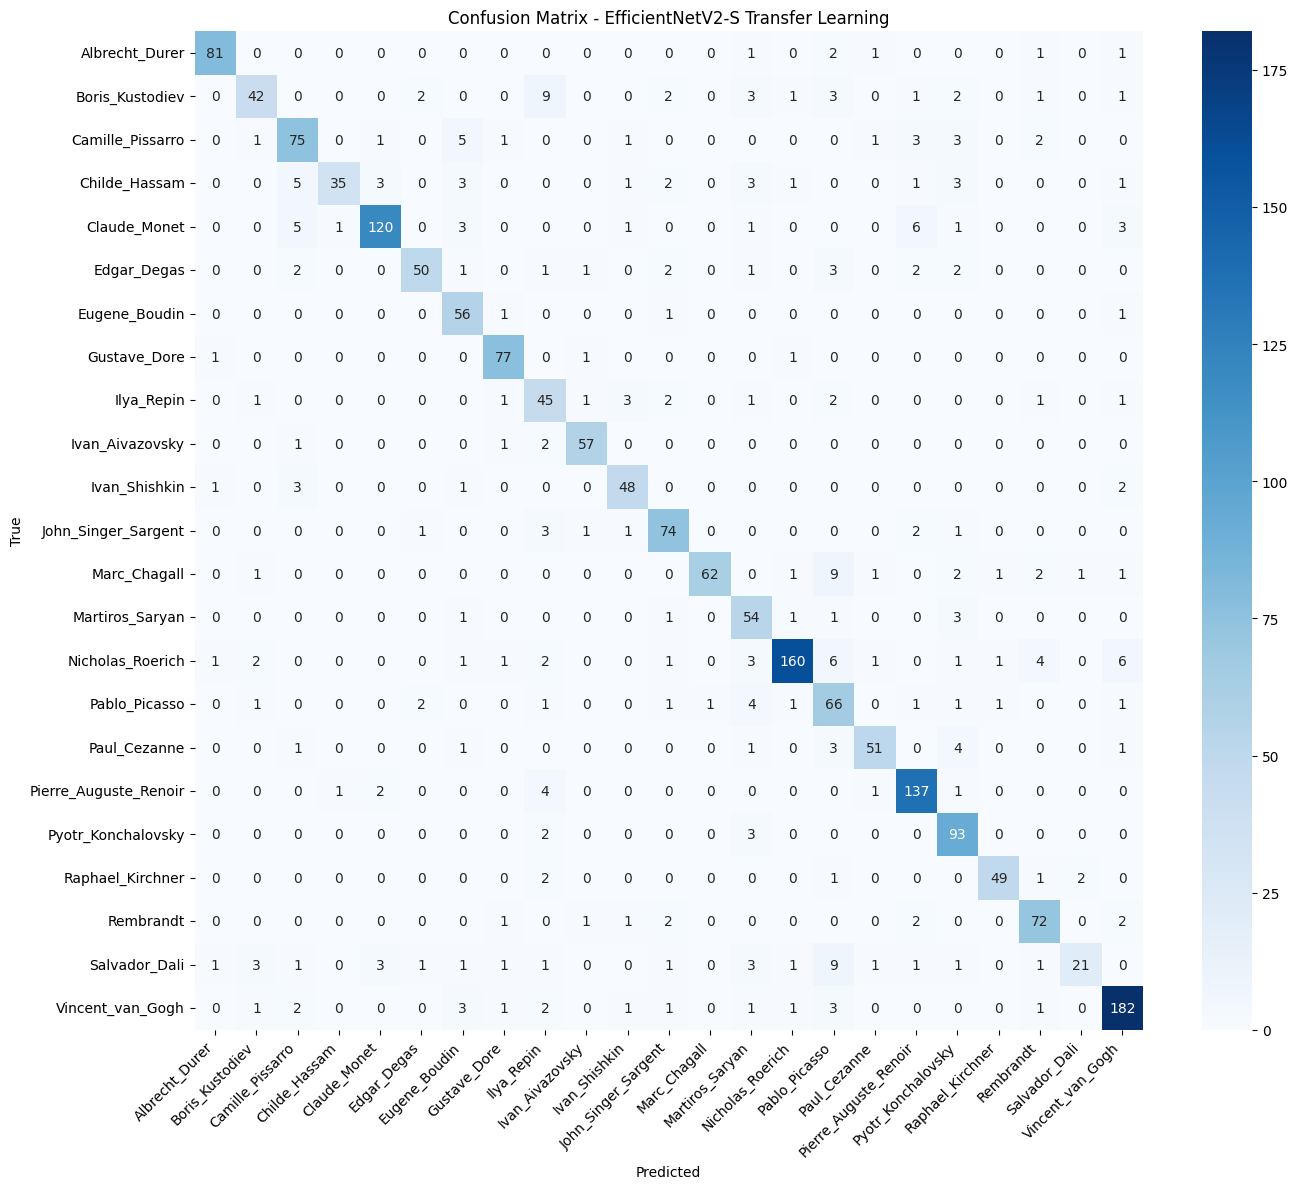

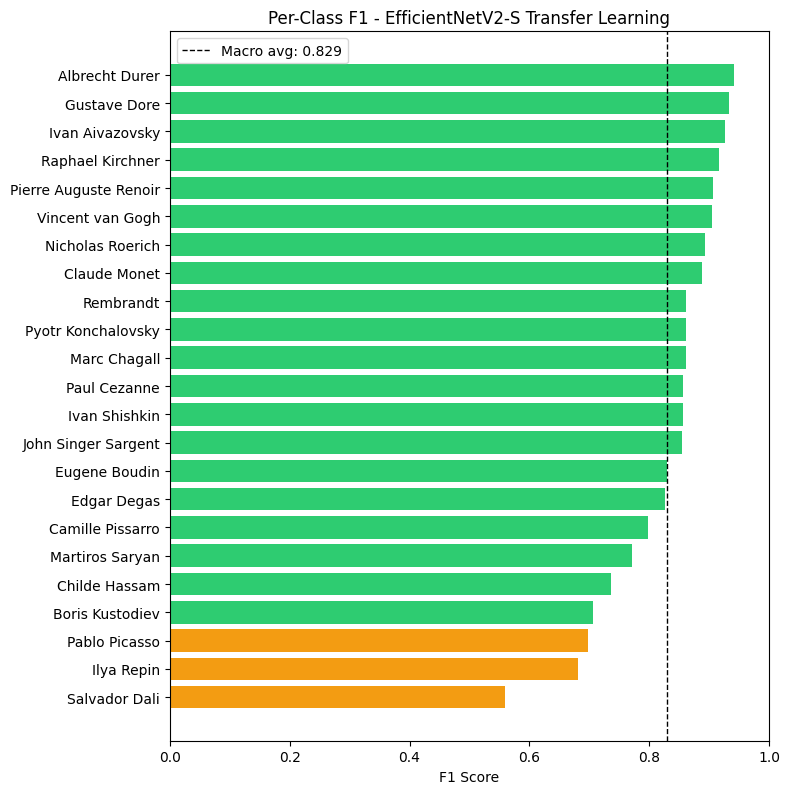

In [10]:
metrics_effnetv2s = evaluate_model(model, test_ds, class_names, "EfficientNetV2-S Transfer Learning")


In [ ]:
save_history([history_phase1, history_phase2], history_path)


### Test Evaluation with TTA

As in the ResNet50 notebook, the final evaluation (inference + TTA) is executed **locally** to avoid hitting the Colab quota. The best checkpoint is downloaded from Drive and reloaded with `keras.models.load_model()`. Here we do the same thing.


In [2]:
# Load the trained model
model = keras.models.load_model(
    "../models/EfficientNetV2S/effnetv2s_v1_best.keras",
    compile=False,
)

# Recompile (needed so model.evaluate() works inside evaluate_model and predict_tta)
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-5),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"],
)


In [3]:
IMG_SIZE = (300, 300)
BATCH_SIZE = 16

# All paths relative to notebooks/
train_dir = config['paths']['train_dir']
val_dir   = config['paths']['val_dir']
test_dir  = config['paths']['test_dir']

_, _, test_ds, class_names = load_datasets(
    train_dir, val_dir, test_dir,
    img_size=IMG_SIZE, batch_size=BATCH_SIZE,
)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)


Found 9282 files belonging to 23 classes.
Found 1980 files belonging to 23 classes.
Found 2012 files belonging to 23 classes.
Classes (23): ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']



  EfficientNetV2-S - Test Evaluation
  Test Loss:     1.1250
  Test Accuracy: 0.8484
  Test F1 Macro: 0.8294

Classification Report:
                       precision    recall  f1-score   support

       Albrecht_Durer       0.95      0.93      0.94        87
      Boris_Kustodiev       0.81      0.63      0.71        67
     Camille_Pissarro       0.79      0.81      0.80        93
        Childe_Hassam       0.95      0.60      0.74        58
         Claude_Monet       0.93      0.85      0.89       141
          Edgar_Degas       0.89      0.77      0.83        65
        Eugene_Boudin       0.74      0.95      0.83        59
         Gustave_Dore       0.91      0.96      0.93        80
           Ilya_Repin       0.61      0.78      0.68        58
      Ivan_Aivazovsky       0.92      0.93      0.93        61
        Ivan_Shishkin       0.84      0.87      0.86        55
  John_Singer_Sargent       0.82      0.89      0.86        83
         Marc_Chagall       0.98      0.77    

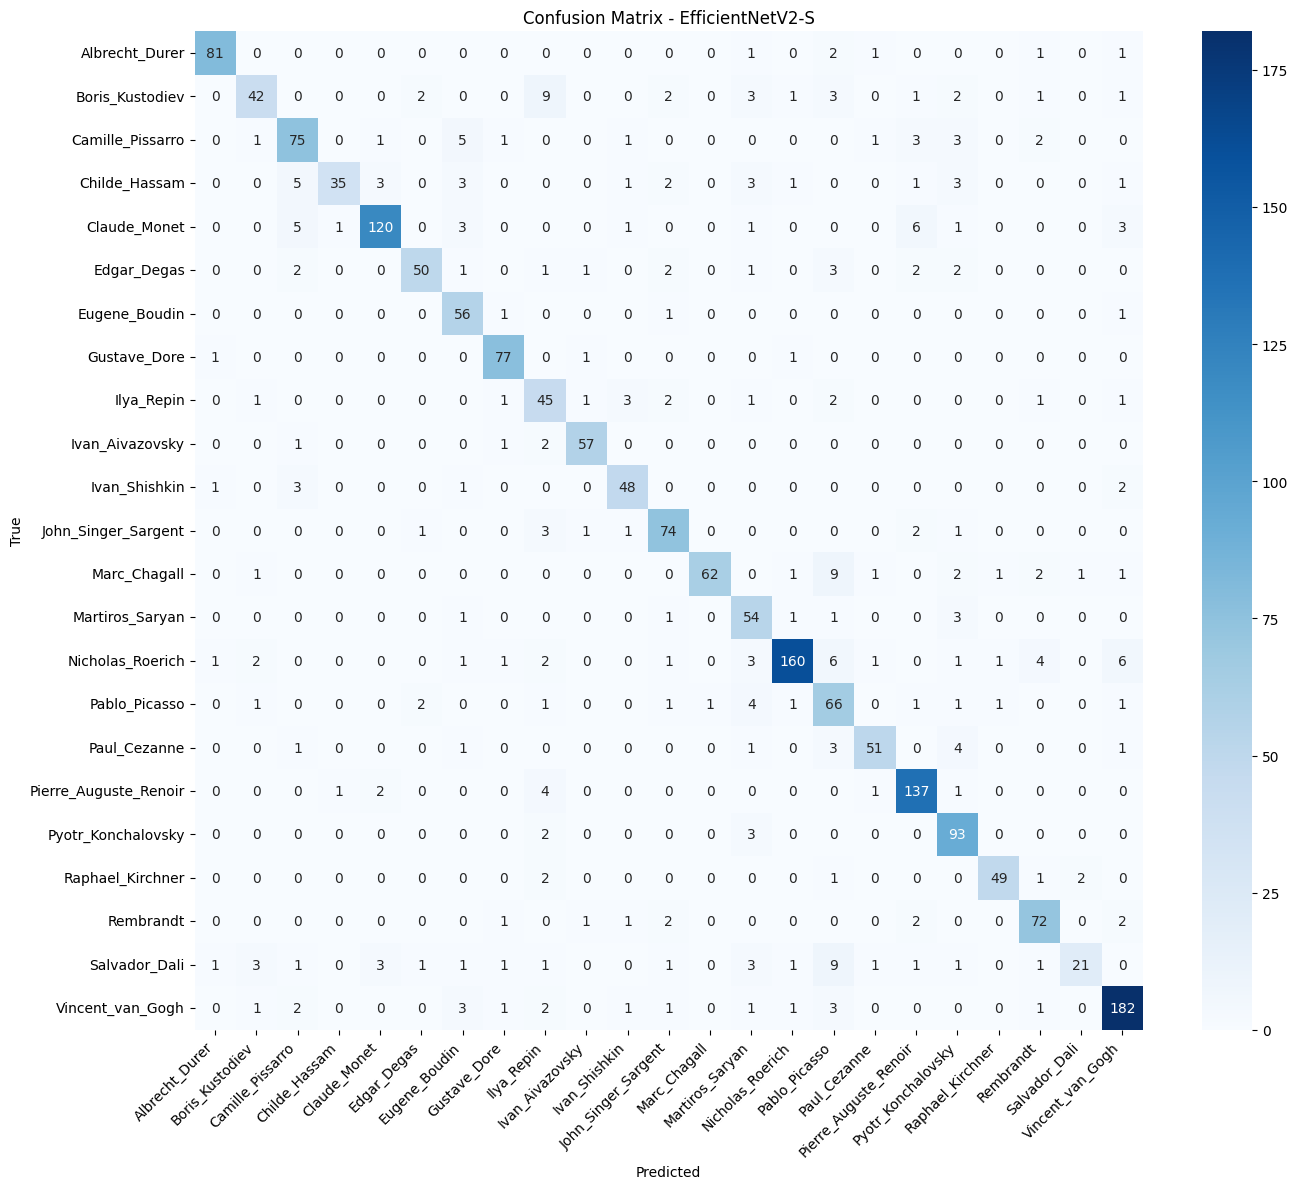

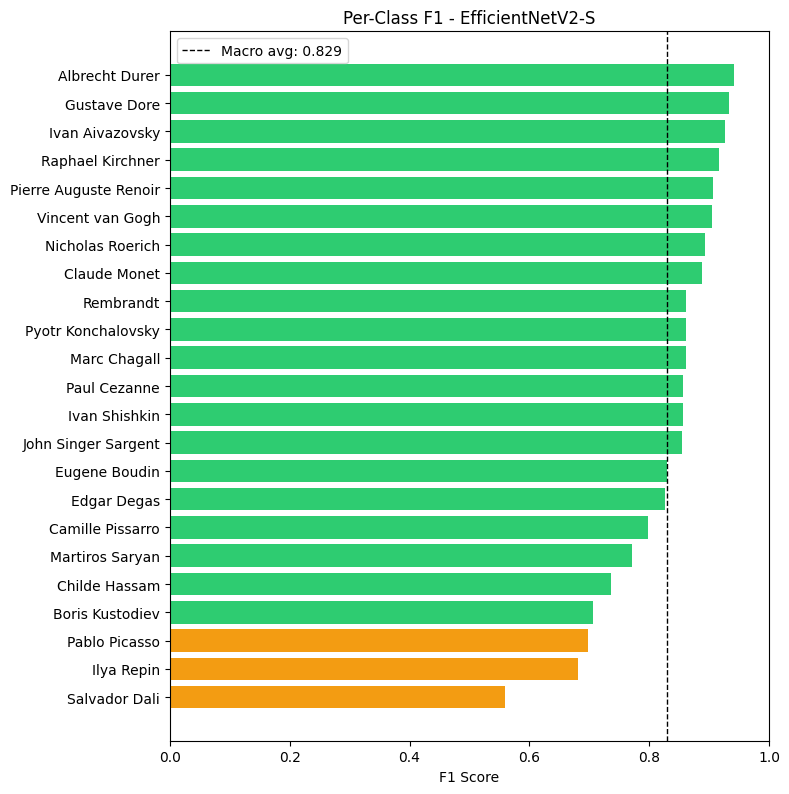

In [4]:
metrics_effnetv2s = evaluate_model(model, test_ds, class_names, "EfficientNetV2-S")


In [9]:
test_loss_tta, test_acc_tta, test_f1_tta, y_true_tta, y_pred_tta, probs_tta = predict_tta(
    model, test_ds, n_augmentations=5
)


TTA Results - Loss: 1.1250 | Accuracy: 0.8743 | F1: 0.8602



  EfficientNetV2-S + TTA - Test Evaluation
  Test Loss:     1.1250
  Test Accuracy: 0.8743
  Test F1 Macro: 0.8602

Classification Report:
                       precision    recall  f1-score   support

       Albrecht_Durer       0.96      0.94      0.95        87
      Boris_Kustodiev       0.78      0.73      0.75        67
     Camille_Pissarro       0.84      0.81      0.82        93
        Childe_Hassam       0.88      0.72      0.79        58
         Claude_Monet       0.88      0.92      0.90       141
          Edgar_Degas       0.86      0.86      0.86        65
        Eugene_Boudin       0.80      0.90      0.85        59
         Gustave_Dore       0.93      0.96      0.94        80
           Ilya_Repin       0.73      0.69      0.71        58
      Ivan_Aivazovsky       0.88      0.95      0.91        61
        Ivan_Shishkin       0.86      0.87      0.86        55
  John_Singer_Sargent       0.85      0.90      0.88        83
         Marc_Chagall       0.97      0.

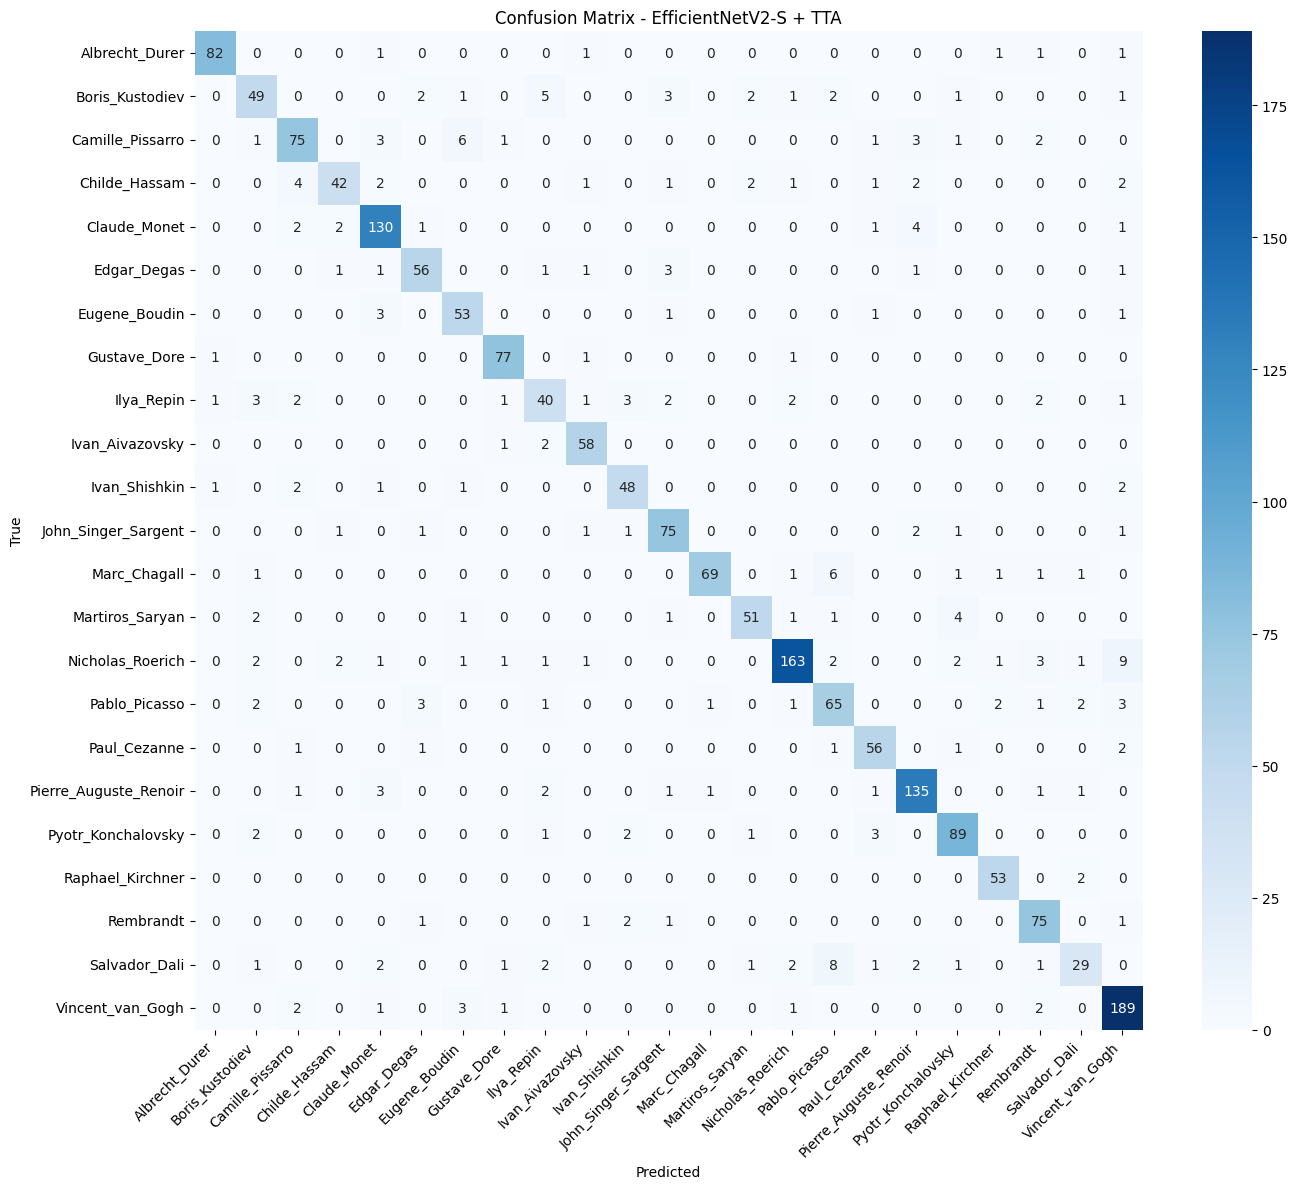

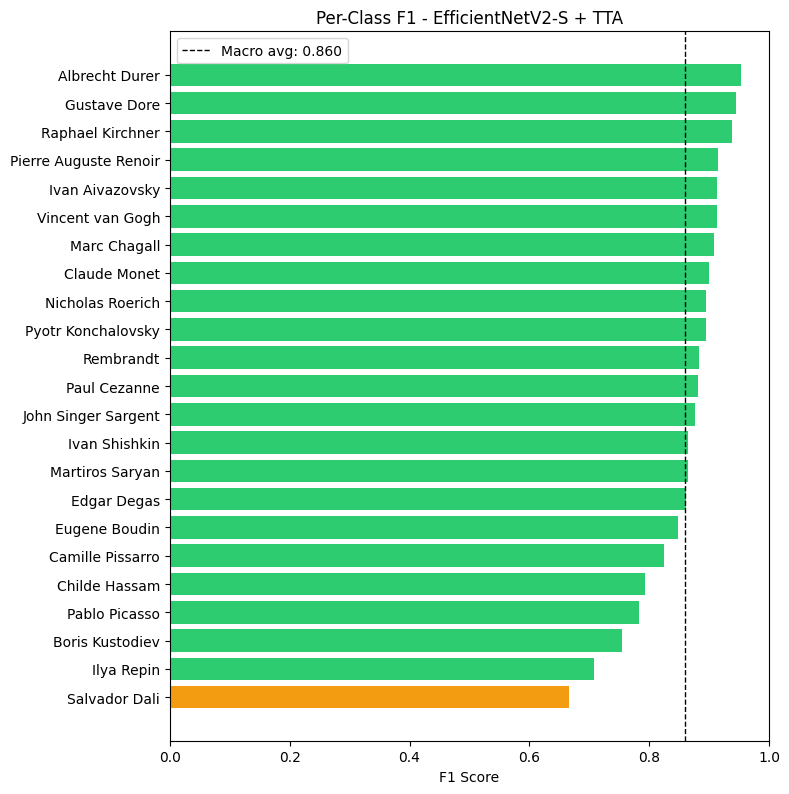

In [10]:
metrics_effnetv2s_tta = evaluate_from_predictions(
    y_true_tta, y_pred_tta, probs_tta,
    class_names,
    model_name="EfficientNetV2-S + TTA",
    test_loss=test_loss_tta,
)
